# **Imports**

In [1]:
!pip install pmdarima
!pip install git+https://github.com/scikit-learn-contrib/py-earth@v0.2dev

     |████████████████████████████████| 1.5 MB 7.0 MB/s 
     |████████████████████████████████| 9.5 MB 70.5 MB/s 
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.10.2
    Uninstalling statsmodels-0.10.2:
      Successfully uninstalled statsmodels-0.10.2
  Cloning https://github.com/scikit-learn-contrib/py-earth (to revision v0.2dev) to /tmp/pip-req-build-cpncz87v
  Running command git clone -q https://github.com/scikit-learn-contrib/py-earth /tmp/pip-req-build-cpncz87v
  Running command git checkout -b v0.2dev --track origin/v0.2dev
  Switched to a new branch 'v0.2dev'
  Branch 'v0.2dev' set up to track remote branch 'v0.2dev' from 'origin'.
  Created wheel for sklearn-contrib-py-earth: filename=sklearn_contrib_py_earth-0.1.0+16.g400f84d-cp37-cp37m-linux_x86_64.whl size=3997352 sha256=da7d06206cd956f999842335e2236a684125d4b99afbcfacf43677cafbae05f0
  Stored in directory: /tmp/pip-ephem-wheel-cache-ogn6s5ne/wheels/79/d7/aa/1e418a9aea84424ef2ce2697ae7c

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import datetime
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import sklearn
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots  import plot_acf as pltacf
from  statsmodels.tsa.stattools import pacf as PACF
from statsmodels.graphics.tsaplots  import plot_pacf as pltpacf
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

In [3]:
!gdown --id 1uhxjs5UNSTrKvkjhJhyCY_I5Hx4ep6WX

Downloading...
From: https://drive.google.com/uc?id=1uhxjs5UNSTrKvkjhJhyCY_I5Hx4ep6WX
To: /content/DIVISLAB.NS.csv
100% 152k/152k [00:00<00:00, 1.33MB/s]


In [4]:
stock_name="DIVISLAB"

In [5]:
df_stock = pd.read_csv('DIVISLAB.NS.csv',index_col='Date')
df_stock.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,1154.0,1165.000000,1145.550049,1162.500000,100178.0,4,1,1,7791.299805,19.449951
2016-01-04,1161.0,1173.699951,1137.800049,1149.699951,233101.0,0,4,1,7784.649902,35.899902
2016-01-05,1147.0,1157.500000,1138.500000,1147.500000,302272.0,1,5,1,7741.000000,19.000000
2016-01-06,1149.0,1154.300049,1135.000000,1137.199951,392164.0,2,6,1,7568.299805,19.300049
2016-01-07,1115.0,1136.550049,1115.000000,1126.949951,316523.0,3,7,1,7601.350098,21.550049


#**ARIMA - Autoregression Intergrated Moving Average**

##*Decomposing the data*

In [6]:
df_stock['Close'].head()

Date
2016-01-01    1162.500000
2016-01-04    1149.699951
2016-01-05    1147.500000
2016-01-06    1137.199951
2016-01-07    1126.949951
Name: Close, dtype: float64

Text(0.5, 1.0, 'Close Price - DIVISLAB')

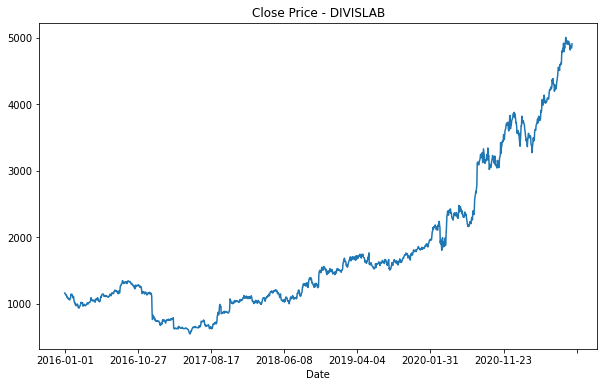

In [7]:
plt.rcParams['figure.figsize'] = (10,6)
df_stock['Close'].plot()
plt.title("Close Price - "+stock_name)

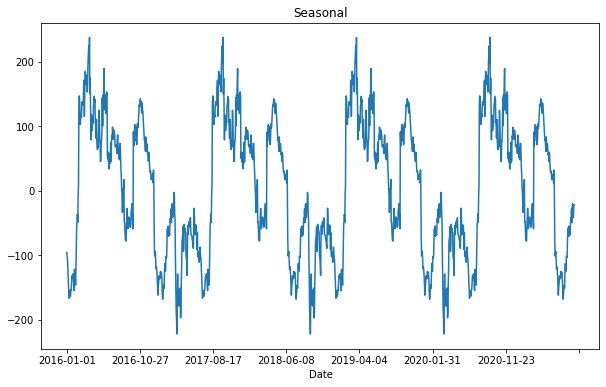

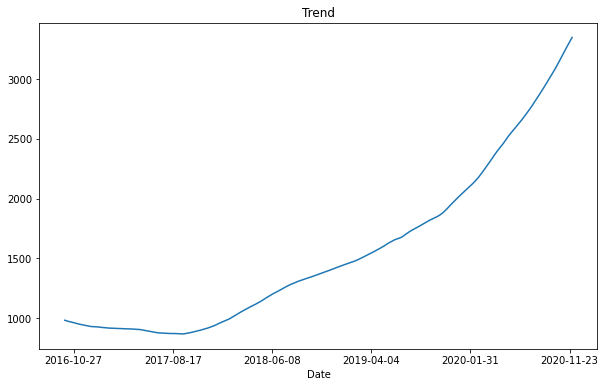

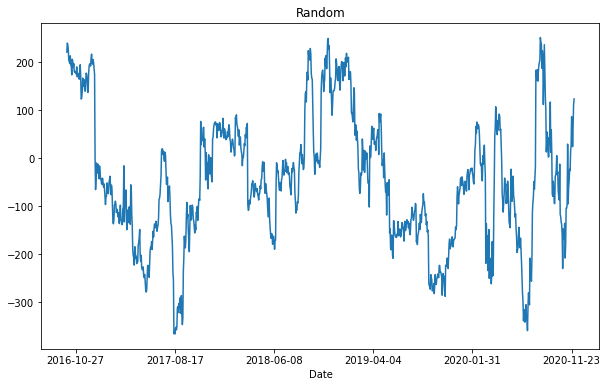

In [8]:
plt.rcParams['figure.figsize'] = (10,6)
decomposition=seasonal_decompose(df_stock['Close'],freq=365)
decomposition.seasonal.plot()
plt.title("Seasonal")
plt.show()
decomposition.trend.plot()
plt.title("Trend")
plt.show()
decomposition.resid.plot()
plt.title("Random")
plt.show()

##*Stationary Check*

In [9]:
Stationary=False
dvalue=0
Stationary_df=df_stock['Close'].copy()
while(Stationary==False):
  dftest = adfuller(Stationary_df.dropna(),autolag='AIC')
  dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
  for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
  print(dftest[1])
  if (dftest[1]>0.05):
    Stationary=False
    Stationary_df = Stationary_df - Stationary_df.shift(1)
  else :
    Stationary=True
  dvalue+=1  
print(dfoutput)
print("Differencing Value : ",dvalue)

0.9990796189377779
0.0
Test Statistic                  -39.277709
p-value                           0.000000
#lags used                        0.000000
number of observations used    1386.000000
critical value (1%)              -3.435077
critical value (5%)              -2.863628
critical value (10%)             -2.567881
dtype: float64
Differencing Value :  2


##*ACF*

In [10]:
from  statsmodels.tsa.stattools import acf as ACF
ACFOutput = ACF(Stationary_df.dropna(),nlags=20)
print(ACFOutput)

[ 1.00000000e+00 -5.50033366e-02  3.56929177e-02  3.05698143e-02
  1.54345112e-02 -1.35382160e-02  2.06389534e-02  3.46864291e-02
  3.60482580e-03  4.36507716e-03 -9.26130343e-03 -1.91192578e-02
  2.30102806e-02  2.19040013e-02 -2.93565969e-02 -2.26801053e-03
  4.47531034e-02  1.51396210e-02 -1.89162139e-02  6.55405844e-04
 -2.35037637e-02]


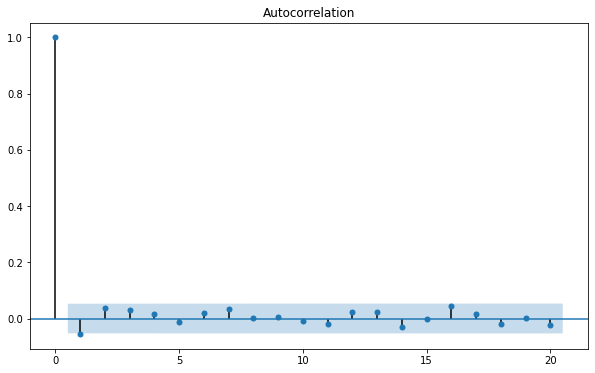

In [11]:
plt.rcParams['figure.figsize'] = (10,6)
pltacf(Stationary_df.dropna(),lags=20)
plt.show()

##*PACF*

In [12]:
PACFOutput = PACF(Stationary_df.dropna(),nlags=20)
print(PACFOutput)

[ 1.         -0.05504302  0.03281414  0.0344867   0.01789914 -0.01414015
  0.01705806  0.03704051  0.0069156   0.00157758 -0.01263109 -0.02174405
  0.02218632  0.02566419 -0.02869371 -0.0090816   0.04464381  0.02449846
 -0.01802628 -0.00905836 -0.0267907 ]


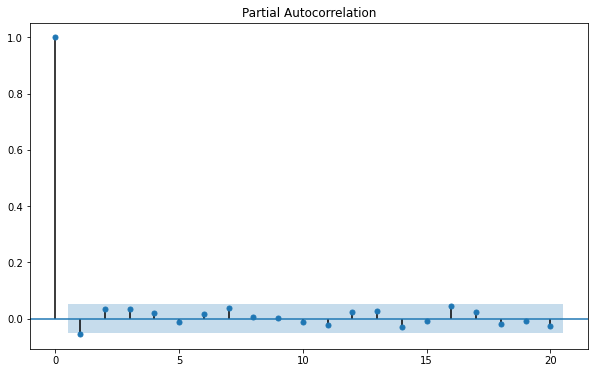

In [13]:
plt.rcParams['figure.figsize'] = (10,6)
pltpacf(Stationary_df.dropna(),lags=20).show()
plt.show()

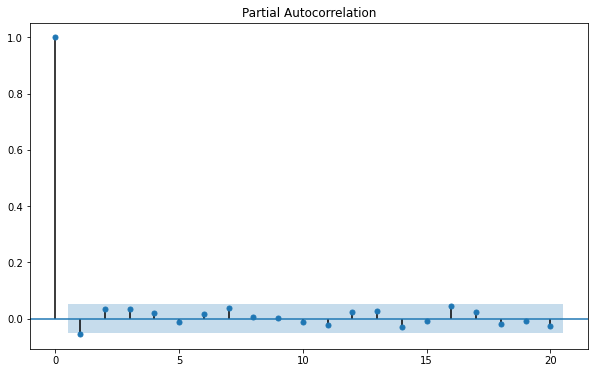

In [78]:
from matplotlib import pyplot
pltpacf(Stationary_df.dropna(),lags=20,ax=pyplot.gca())

##*Test and Train Split*

In [14]:
df_stock_train=df_stock.loc['2016-01-01':'2021-07-31']['Close']
df_stock_test=df_stock.loc['2021-07-31':]['Close']

In [15]:
df_stock_train.tail()

Date
2021-07-26    4921.149902
2021-07-27    4791.399902
2021-07-28    4890.600098
2021-07-29    4843.799805
2021-07-30    4906.100098
Name: Close, dtype: float64

In [16]:
df_stock_test.head()

Date
2021-08-02    4928.950195
2021-08-03    5006.850098
2021-08-04    4964.250000
2021-08-05    4923.549805
2021-08-06    4916.000000
Name: Close, dtype: float64

##*Model Fitting*

In [17]:
arima_model=auto_arima(df_stock_train,seasonal=False,max_p=2,max_d=2,max_q=2,start_p=0,start_q=0,d=1)

In [18]:
arima_model

ARIMA(maxiter=50, method='lbfgs', order=(1, 1, 0), out_of_sample_size=0,
      scoring='mse', scoring_args={}, seasonal_order=(0, 0, 0, 0),
      start_params=None, suppress_warnings=True, trend=None,
      with_intercept=True)

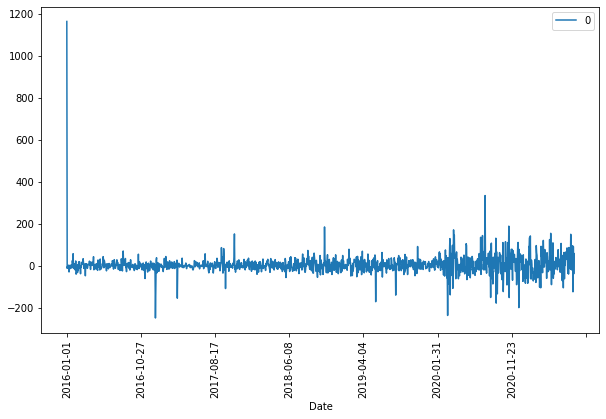

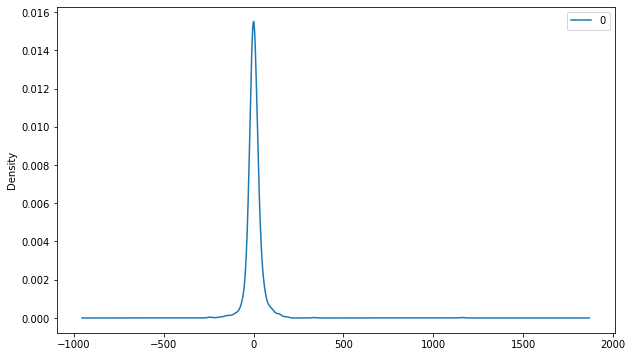

                 0
count  1369.000000
mean      3.679404
std      49.362535
min    -248.985918
25%     -13.446550
50%       0.800664
75%      17.183112
max    1162.500000


In [19]:
model = ARIMA(df_stock_train, order=(1,1,1))
model_fit = model.fit()
residuals = pd.DataFrame(model_fit.resid)
plt.rcParams['figure.figsize'] = (10,6)
residuals.plot()
plt.xticks(rotation=90)
plt.show()
residuals.plot(kind='kde')
plt.show()
print(residuals.describe())

##*Forecasting and Testing*

In [20]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values)):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)
error = np.sqrt(mean_squared_error(df_stock_test.values, predictions))
print('Test Error Percentage',(error/np.mean(df_stock_test.values))*100)

Test Error Percentage 0.854928783783886


([], <a list of 0 Text major ticklabel objects>)

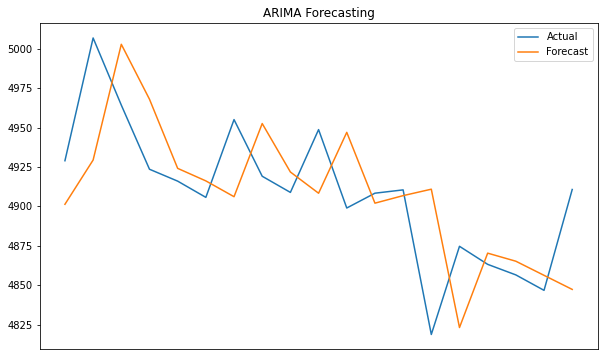

In [21]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(df_stock_test, label='Actual')
plt.plot(predictions, label='Forecast')
plt.title('ARIMA Forecasting')
plt.legend()
plt.xticks([])

##*Forecast for August*

In [22]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values[:14])):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)

In [23]:
predictions

[4901.3095597632255,
 4929.397929522329,
 5002.835764225187,
 4967.971205990904,
 4924.1069799972265,
 4916.151286561096,
 4906.127444115527,
 4952.5495408837305,
 4921.7961288714205,
 4908.326715923364,
 4946.962252923704,
 4902.023320722064,
 4906.802860216723,
 4910.888279173102]

#**MARS - Multivariate Adaptive Regression Splines**

In [24]:
from pyearth import Earth

In [25]:
df_stock_mars_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:5].copy()
df_stock_mars_test=df_stock.loc['2021-07-31':].iloc[:,:5].copy()

In [26]:
df_stock_mars_train.shape

(1369, 5)

In [27]:
df_stock_mars_test.shape

(19, 5)

In [28]:
df_stock_mars_train.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-01-01,1154.0,1165.000000,1145.550049,1162.500000,100178.0
2016-01-04,1161.0,1173.699951,1137.800049,1149.699951,233101.0
2016-01-05,1147.0,1157.500000,1138.500000,1147.500000,302272.0
2016-01-06,1149.0,1154.300049,1135.000000,1137.199951,392164.0
2016-01-07,1115.0,1136.550049,1115.000000,1126.949951,316523.0


In [29]:
df_stock_mars_test

,Open,High,Low,Close,Volume
Date,,,,,
2021-08-02,4893.500000,4962.149902,4893.500000,4928.950195,359231.0
2021-08-03,4930.600098,5019.899902,4900.000000,5006.850098,530586.0
2021-08-04,5017.000000,5045.200195,4954.549805,4964.250000,381205.0
2021-08-05,5000.000000,5020.000000,4916.500000,4923.549805,413085.0
2021-08-06,4950.000000,4959.000000,4884.000000,4916.000000,314260.0
2021-08-09,4980.000000,4989.799805,4831.000000,4905.700195,955464.0
2021-08-10,4930.899902,4971.600098,4895.000000,4955.049805,356348.0
2021-08-11,4954.500000,4958.950195,4840.799805,4919.100098,354008.0
2021-08-12,4929.950195,4929.950195,4872.000000,4908.850098,200081.0


In [30]:
x_train_mars = df_stock_mars_train.drop(['Close'], axis=1)
y_train_mars = df_stock_mars_train['Close']
x_test_mars = df_stock_mars_test.drop(['Close'], axis=1)
y_test_mars = df_stock_mars_test['Close']

##*Fitting the model*

In [31]:
MARS_model = Earth(max_terms = 600,max_degree=3)
MARS_model_fitted = MARS_model.fit(x_train_mars, y_train_mars)
y_pred_mars = MARS_model_fitted.predict(x_test_mars[:14])

##*Evaluating the model*

In [32]:
MSE = mean_squared_error(y_test_mars[:14], y_pred_mars)
RMSE = np.sqrt(MSE)
RMSE_mean = (RMSE/np.mean(y_test_mars[:14]))*100
print("RMSE Score :", round(RMSE, 2))
print("RMSE/Mean", round(RMSE_mean,1))

RMSE Score : 32.88
RMSE/Mean 0.7


##*Plotting Forecast vs Actual* 

([], <a list of 0 Text major ticklabel objects>)

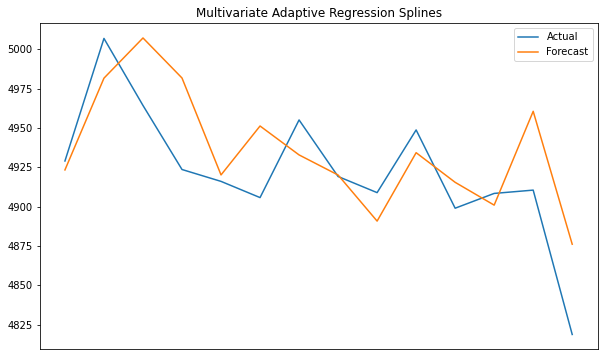

In [33]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(y_test_mars[:14], label='Actual')
plt.plot(y_pred_mars, label='Forecast')
plt.title('Multivariate Adaptive Regression Splines')
plt.legend()
plt.xticks([])

#**VAR - Vector Autoregression**

In [34]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic

In [35]:
df_stock_var = df_stock.loc['2016-01-01':'2021-08-20'].iloc[:,:4].copy()
df_stock_var_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:4].copy()
df_stock_var_test=df_stock.loc['2021-07-31':'2021-08-20'].iloc[:,:4].copy()


In [36]:
df_stock_var_train.shape

(1369, 4)

In [37]:
df_stock_var_test.shape

(14, 4)

In [38]:
df_stock_var.shape

(1383, 4)

##*Plotting the Data*

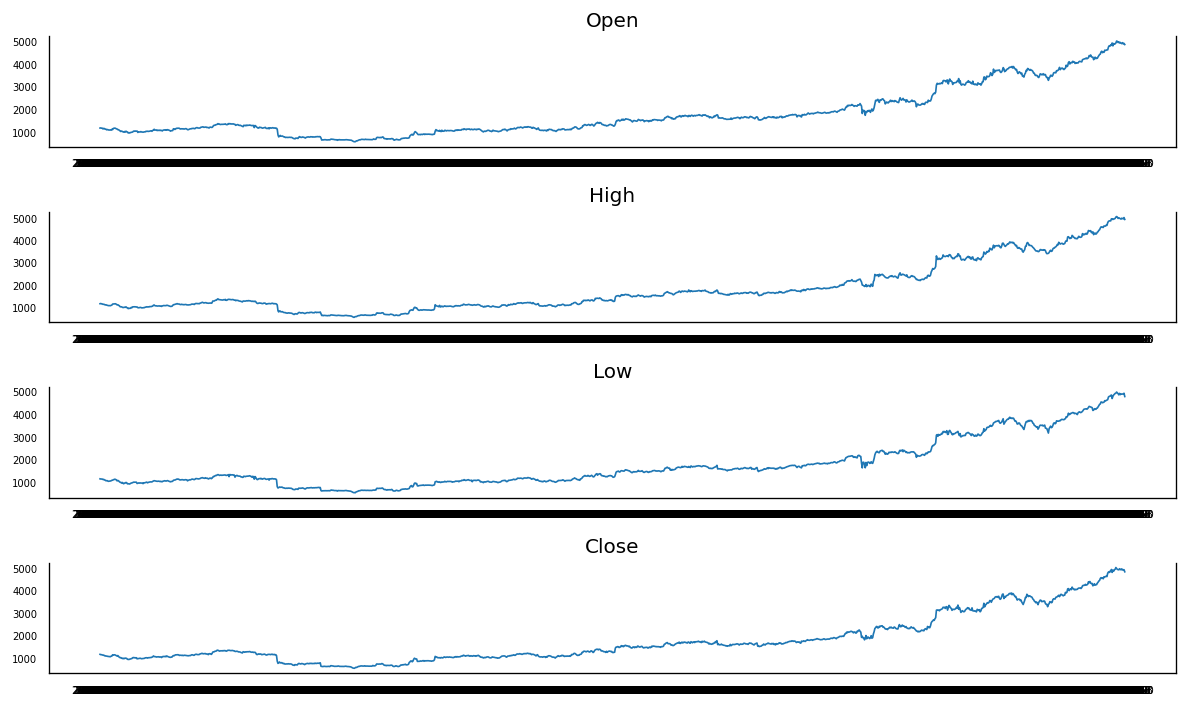

In [39]:
fig, axes = plt.subplots(nrows=4, ncols=1, dpi=120, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = df_stock_var[df_stock_var.columns[i]]
    ax.plot(data, linewidth=1)
    # Decorations
    ax.set_title(df_stock_var.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout();

##*Granger Causality Test*

In [40]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

grangers_causation_matrix(df_stock_var, variables = df_stock_var.columns)        

,Open_x,High_x,Low_x,Close_x
Open_y,1.0000,0.0000,0.0000,0.0
High_y,0.0000,1.0000,0.0000,0.0
Low_y,0.0000,0.0000,1.0000,0.0
Close_y,0.0089,0.0016,0.1758,1.0


##*Cointegration Test*

In [41]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df_stock_var, alpha=0.05): 
    out = coint_johansen(df_stock_var,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    print('Name   ::  Test Statistic > C(95%)    =>   Significance  \n', '--'*20)
    for col, trace, cvt in zip(df_stock_var.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)

cointegration_test(df_stock_var)

Name   ::  Test Statistic > C(95%)    =>   Significance  
 ----------------------------------------
Open   ::  478.92    > 40.1749   =>   True
High   ::  267.15    > 24.2761   =>   True
Low    ::  85.31     > 12.3212   =>   True
Close  ::  9.69      > 4.1296    =>   True


##*ADF Test*

In [42]:
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue'] 
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")    

In [43]:
# ADF Test on each column
for name, column in df_stock_var_train.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = 2.5158
 No. Lags Chosen       = 10
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.9991. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = 2.6903
 No. Lags Chosen       = 1
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.9991. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root

##*ADF Test on first order differencing*

In [44]:
df_differenced = df_stock_var_train.diff().dropna()

In [45]:
# ADF Test on each column of 1st Differences Dataframe
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -11.3271
 No. Lags Chosen       = 9
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -34.9968
 No. Lags Chosen       = 0
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05

##*Selecting the number of lags*

In [47]:
model = VAR(df_differenced)
x = model.select_order(maxlags=20)
x.summary()

,AIC,BIC,FPE,HQIC
0,26.99,27.00,5.244e+11,26.99
1,25.35,25.43,1.020e+11,25.38
2,24.88,25.02,6.363e+10,24.93
3,24.58,24.79,4.754e+10,24.66
4,24.47,24.73,4.235e+10,24.57
5,24.34,24.67*,3.730e+10,24.46
6,24.31,24.70,3.624e+10,24.46
7,24.29,24.74,3.532e+10,24.46
8,24.27,24.78,3.455e+10,24.46
9,24.22,24.80,3.313e+10,24.44*


##*Fitting the model*

In [52]:
model_fitted = model.fit(x.aic)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 15, Sep, 2021
Time:                     07:54:34
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    25.3257
Nobs:                     1349.00    HQIC:                   24.5821
Log likelihood:          -23628.9    FPE:                3.03879e+10
AIC:                      24.1368    Det(Omega_mle):     2.43372e+10
--------------------------------------------------------------------
Results for equation Open
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.662924         0.497410            1.333           0.183
L1.Open          -1.058015         0.039632          -26.696           0.000
L1.High           0.087818         0.033983            2.584           0.010


##*Durbin Watson Test*

In [53]:
from statsmodels.stats.stattools import durbin_watson
out = durbin_watson(model_fitted.resid)

for col, val in zip(df_stock_var.columns, out):
    print(col, ':', round(val, 2))

Open : 1.99
High : 2.0
Low : 1.99
Close : 2.0


##*Getting the Forecast*

In [54]:
# Get the lag order
lag_order = model_fitted.k_ar
print(lag_order)

# Input data for forecasting
forecast_input = df_differenced.values[-lag_order:]
forecast_input

19


array([[  98.29980469,   52.94970703,   86.25      ,   40.30029297],
       [  31.        ,   -1.04980469,   -5.14990234,  -35.75      ],
       [ -65.        ,  -15.95019531,  -27.10009766,   28.34960938],
       [  33.        ,   -6.04980469,   15.        ,  -42.04980469],
       [ -18.        ,   65.        ,   10.79980469,   89.20019531],
       [  95.        ,   -1.04980469,   64.85009766,  -10.95019531],
       [ -10.        ,   -5.20019531,   -8.75      ,   17.29980469],
       [   9.5       ,   42.89990234,   18.25      ,   17.15039062],
       [  16.5       ,   -9.25      ,   12.75      ,  -15.90039062],
       [  -1.        ,  119.60009766,   22.10009766,  150.30029297],
       [ 124.95019531,   60.70019531,  115.54980469,   49.85009766],
       [  57.04980469,   15.29980469,   27.45019531,  -19.60009766],
       [ -19.14990234,    8.39990234,    6.39990234,   55.39990234],
       [  55.60009766,   -6.39990234,   32.30029297,  -18.5       ],
       [ -18.70019531,   90.649902

In [55]:
nobs = 14
fc = model_fitted.forecast(y=forecast_input, steps=nobs)
df_forecast = pd.DataFrame(fc, index=df_stock_var.index[-nobs:], columns=df_stock_var.columns + '_1d')
df_forecast

,Open_1d,High_1d,Low_1d,Close_1d
Date,,,,
2021-08-02,37.293671,30.063593,7.769488,21.363187
2021-08-03,1.914199,22.989322,2.455674,17.500867
2021-08-04,31.753401,12.923545,26.275951,21.753088
2021-08-05,6.451376,13.890168,4.829672,9.948701
2021-08-06,18.108927,12.716636,32.567128,14.595948
2021-08-09,1.416460,-6.284053,-19.676285,-20.184323
2021-08-10,-0.575837,7.351079,9.260740,13.482345
2021-08-11,16.601844,18.112808,9.052183,13.249416
2021-08-12,13.426323,-4.188215,19.118470,8.587273


##*Inverting forecast back to original scale*

In [56]:
def invert_transformation(df_train, df_forecast, first_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:        
        if first_diff:
          # Roll back 1st Diff
          df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

In [57]:
df_results = invert_transformation(df_stock_var_train, df_forecast, first_diff=True)        
df_results.loc[:, ['Open_forecast','High_forecast','Low_forecast','Close_forecast']]

,Open_forecast,High_forecast,Low_forecast,Close_forecast
Date,,,,
2021-08-02,4917.243866,4971.013788,4870.019488,4927.463285
2021-08-03,4919.158065,4994.003111,4872.475162,4944.964152
2021-08-04,4950.911467,5006.926655,4898.751114,4966.717240
2021-08-05,4957.362843,5020.816823,4903.580786,4976.665941
2021-08-06,4975.471770,5033.533460,4936.147914,4991.261888
2021-08-09,4976.888230,5027.249407,4916.471629,4971.077565
2021-08-10,4976.312393,5034.600486,4925.732369,4984.559910
2021-08-11,4992.914237,5052.713294,4934.784551,4997.809327
2021-08-12,5006.340561,5048.525079,4953.903022,5006.396599


##*Plotting Forecast vs Actual*

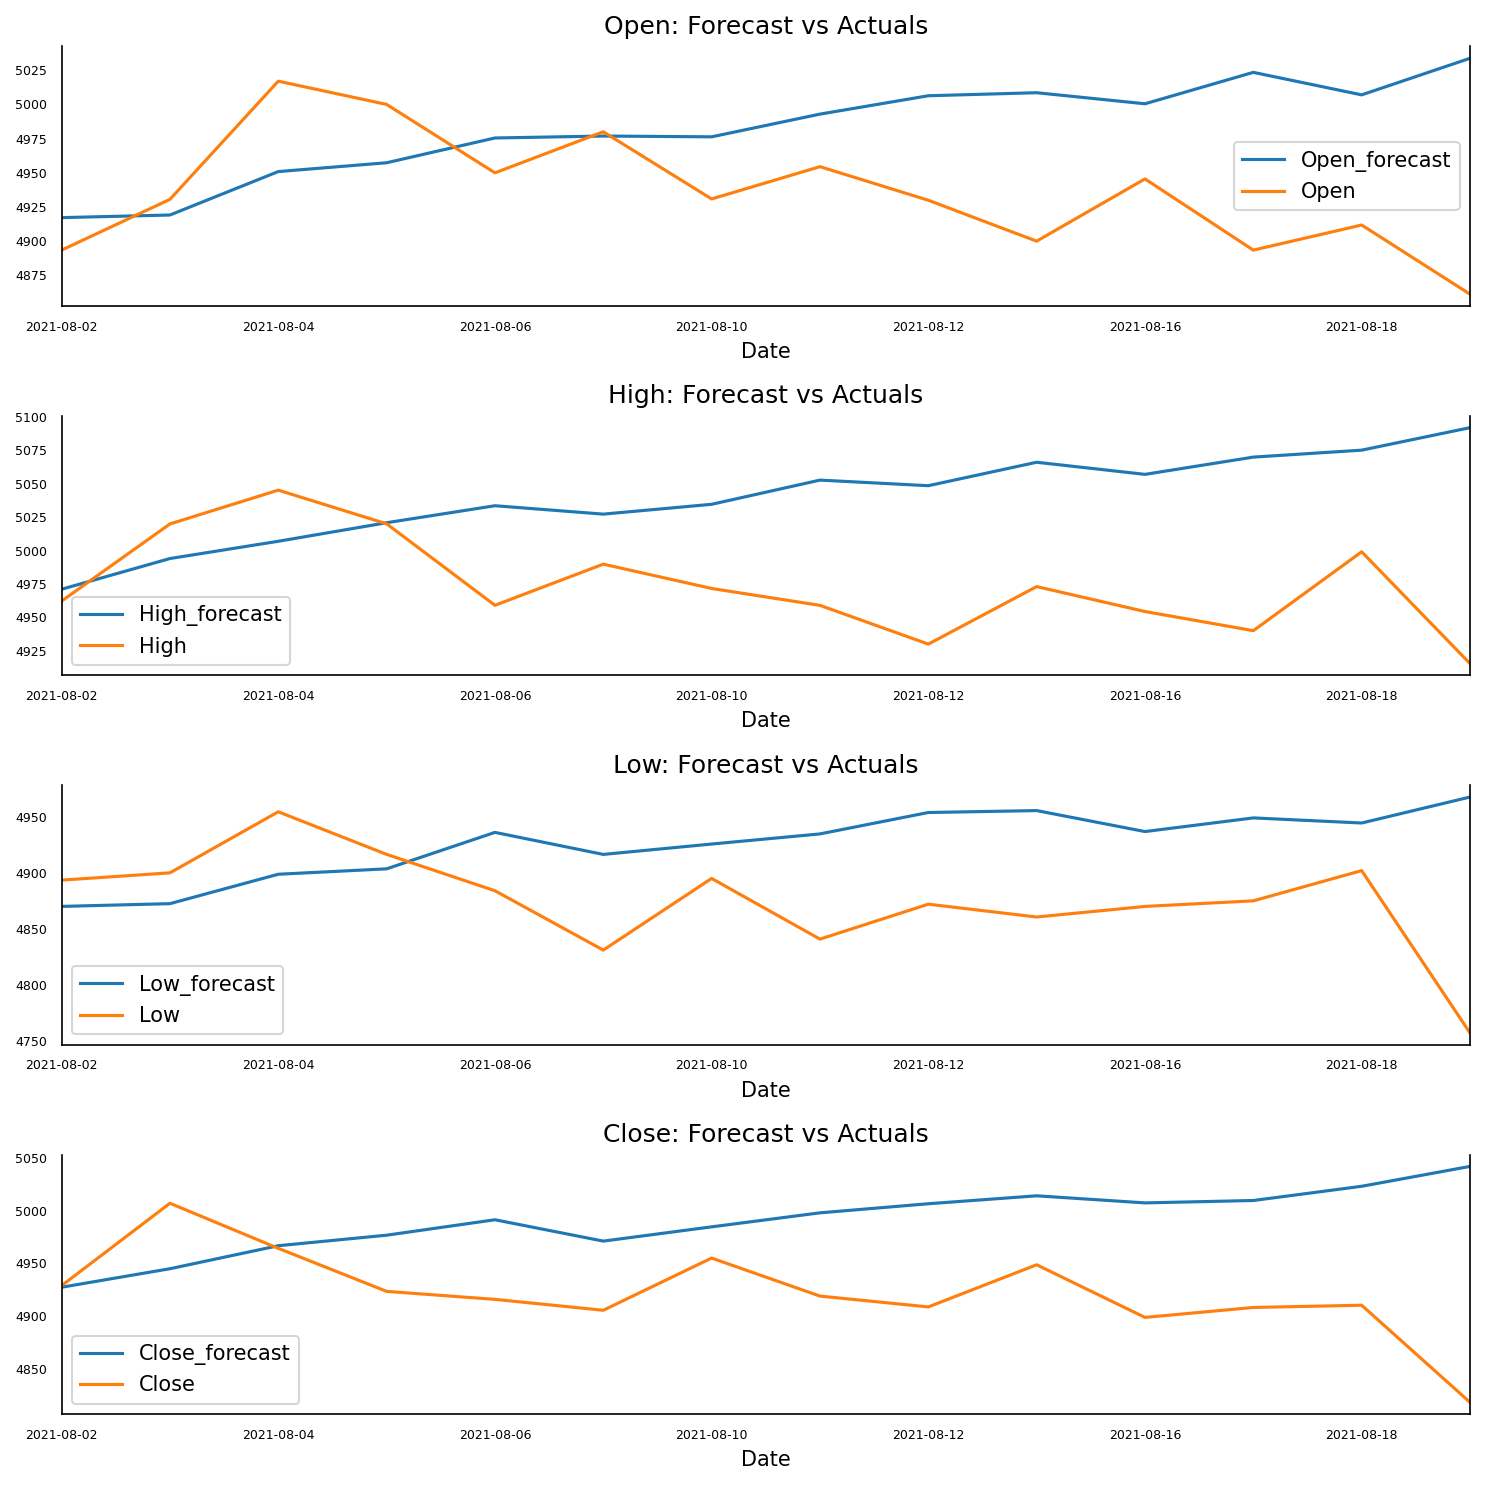

In [58]:
 fig, axes = plt.subplots(nrows=4, ncols=1, dpi=150, figsize=(10,10))
 for i, (col,ax) in enumerate(zip(df_stock_var.columns, axes.flatten())):
   df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
   df_stock_var_test[col][-nobs:].plot(legend=True, ax=ax);
   ax.set_title(col + ": Forecast vs Actuals")
   ax.xaxis.set_ticks_position('none')
   ax.yaxis.set_ticks_position('none')
   ax.spines["top"].set_alpha(0)
   ax.tick_params(labelsize=6)

plt.tight_layout();

##*Evaluating the model*

In [59]:
from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual): 
    rmse = np.mean((forecast - actual)**2)**.5  
    rmse_p = (rmse/np.mean(actual))*100
    return({'rmse':rmse,'rmse_mean':rmse_p})

print('Forecast Accuracy of Open')
accuracy_prod = forecast_accuracy(df_results['Open_forecast'].values, df_stock_var_test['Open'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of High')
accuracy_prod = forecast_accuracy(df_results['High_forecast'].values, df_stock_var_test['High'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Low')
accuracy_prod = forecast_accuracy(df_results['Low_forecast'].values, df_stock_var_test['Low'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Close')
accuracy_prod = forecast_accuracy(df_results['Close_forecast'].values, df_stock_var_test['Close'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))



Forecast Accuracy of Open
rmse :  78.998
rmse_mean :  1.6006

Forecast Accuracy of High
rmse :  88.2549
rmse_mean :  1.7743

Forecast Accuracy of Low
rmse :  82.9411
rmse_mean :  1.7013

Forecast Accuracy of Close
rmse :  93.2519
rmse_mean :  1.8944


#**Linear Regression**

In [60]:
df_stock_train_lin=df_stock.loc['2016-01-01':'2021-07-31'].copy()
df_stock_test_lin=df_stock.loc['2021-07-31':].copy()


##*Normalize the data*

In [61]:
from sklearn.preprocessing import MinMaxScaler

In [62]:
scaler = MinMaxScaler()
df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.fit_transform(df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])
df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.transform(df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])

In [63]:
df_stock_train_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,0.139079,0.138096,0.141560,1162.500000,0.000084,4,1,1,0.091661,0.040931
2016-01-04,0.140675,0.140080,0.139770,1149.699951,0.006552,0,4,1,0.090919,0.086273
2016-01-05,0.137483,0.136386,0.139932,1147.500000,0.009918,1,5,1,0.086044,0.039691
2016-01-06,0.137939,0.135656,0.139124,1137.199951,0.014293,2,6,1,0.066755,0.040518
2016-01-07,0.130187,0.131609,0.134504,1126.949951,0.010612,3,7,1,0.070447,0.046720


In [64]:
df_stock_test_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2021-08-02,0.991678,1.003968,1.007218,4928.950195,0.012690,0,2,8,1.023069,0.176543
2021-08-03,1.000137,1.017137,1.008719,5006.850098,0.021029,1,3,8,1.037370,0.317806
2021-08-04,1.019836,1.022906,1.021318,4964.250000,0.013759,2,4,8,1.041369,0.237184
2021-08-05,1.015960,1.017159,1.012530,4923.549805,0.015311,3,5,8,1.035070,0.272602
2021-08-06,1.004560,1.003249,1.005024,4916.000000,0.010502,4,6,8,1.037309,0.194046


##*Checking for multicollinearity*

In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor    

def calculate_vif_(X, thresh=10,verbose=True):
    cols = X.columns
    variables = np.arange(X.shape[1])
    dropped=True
    while dropped:
        dropped=False
        c = X[cols[variables]].values
        vif = [variance_inflation_factor(c, ix) for ix in np.arange(c.shape[1])]
        

        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            if verbose == True:
                print('dropping \'' + X[cols[variables]].columns[maxloc] + '\' at index: ' + str(maxloc))
            variables = np.delete(variables, maxloc)
            dropped=True
    if verbose == True:
        print('Remaining variables:')
        print(X.columns[variables])
    return X[cols[variables]]

##*Model Generation*

In [66]:
def forward_regression(X, y,
                       threshold_in,
                       verbose=False):
    initial_list = []
    included = list(initial_list)
    while True:
        changed=False
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        if not changed:
            break

    return included

In [67]:
def backward_regression(X, y,
                           threshold_out,
                           verbose=False):
    included=list(X.columns)
    while True:
        changed=False
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() 
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [68]:
def model_generator(df_train,df_test):
    train_dummy=pd.get_dummies(df_train,columns=['Day of Week','Day of Month','Month'])
    test_dummy = pd.get_dummies(df_test,columns=['Day of Week','Day of Month','Month'])
    for i in [1,2,3,4,5,6,7,9,10,11,12]:
        test_dummy['Month_'+str(i)] = 0
        test_dummy['Month_'+str(i)] = test_dummy['Month_'+str(i)].astype('uint8')
    for i in range(1,32):
      if (i not in df_test['Day of Month'].unique()):
        test_dummy['Day of Month_'+str(i)] = 0
        test_dummy['Day of Month_'+str(i)] = test_dummy['Day of Month_'+str(i)].astype('uint8')   
    X=train_dummy.drop('Close',axis=1)
    y=train_dummy["Close"]
    X_f=calculate_vif_(X.select_dtypes(exclude='uint8'),10,False)
    X_f=pd.concat([X_f,X.iloc[:,6:]],axis=1)
    model=sm.OLS(y,X_f[backward_regression(X_f,y,0.01)],axis=1).fit()
    pred=model.predict(test_dummy[backward_regression(X_f,y,0.01)])
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(test_dummy['Close'], pred))
    rmse_pct= (rmse/np.mean(test_dummy['Close']))*100
    sig_var = model.pvalues.index.tolist()
    return model,sig_var,rmse_pct    

In [69]:
 model,variables,rmse_per = model_generator(df_stock_train_lin,df_stock_test_lin)

In [70]:
print(model.summary2())

                   Results: Ordinary least squares
Model:                OLS              Adj. R-squared:     0.999     
Dependent Variable:   Close            AIC:                13662.6638
Date:                 2021-09-15 07:55 BIC:                13751.4350
No. Observations:     1369             Log-Likelihood:     -6814.3   
Df Model:             16               F-statistic:        7.123e+04 
Df Residuals:         1352             Prob (F-statistic): 0.00      
R-squared:            0.999            Scale:              1248.6    
---------------------------------------------------------------------
                Coef.   Std.Err.     t     P>|t|    [0.025    0.975] 
---------------------------------------------------------------------
Open          4382.9999   4.1262 1062.2245 0.0000 4374.9053 4391.0944
Day of Week_0  381.0991   2.1942  173.6846 0.0000  376.7947  385.4035
Day of Week_1  382.2708   2.1760  175.6796 0.0000  378.0021  386.5394
Day of Week_2  382.7929   2.1569  177.4

In [71]:
print("Significance Variables :",'\n',*variables,sep='\n')

Significance Variables :


Open
Day of Week_0
Day of Week_1
Day of Week_2
Day of Week_3
Day of Week_4
Month_1
Month_2
Month_3
Month_4
Month_5
Month_6
Month_7
Month_8
Month_9
Month_10
Month_11
Month_12


In [72]:
print("RMSE Percentage",rmse_per,sep='\n')

RMSE Percentage
0.8986093085074892


##*Univariate Forecasting with ARIMA for Linear Regression*

In [68]:
print("Forecasting Variables :",'\n',list(set(variables) & set(list(df_stock.columns))),sep='\n')

Forecasting Variables :


['Open']


In [69]:
df_stock_for_test_lin=df_stock_test_lin.iloc[:14].copy()
dummy_df = pd.DataFrame(index=df_stock_for_test_lin.index)

In [70]:
Stationary=False
dvalue=0
Stationary_df=df_stock['Open'].copy()
while(Stationary==False):
  dftest = adfuller(Stationary_df.dropna(),autolag='AIC')
  dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
  for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
  
  if (dftest[1]>0.05):
    Stationary=False
    Stationary_df = Stationary_df - Stationary_df.shift(1)
  else :
    Stationary=True
  dvalue+=1  
print("Differencing Value : ",dvalue)

Differencing Value :  1


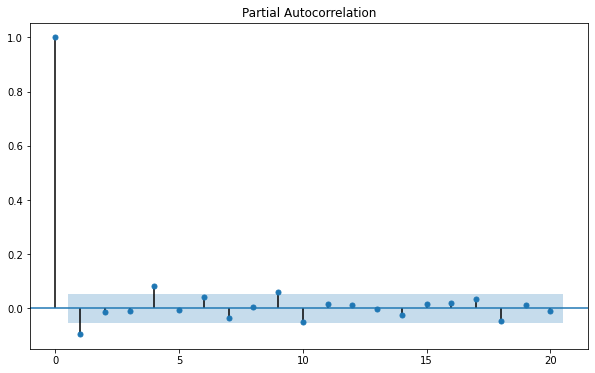

In [71]:
pltpacf(Stationary_df.dropna(),lags=20).show()
plt.show()

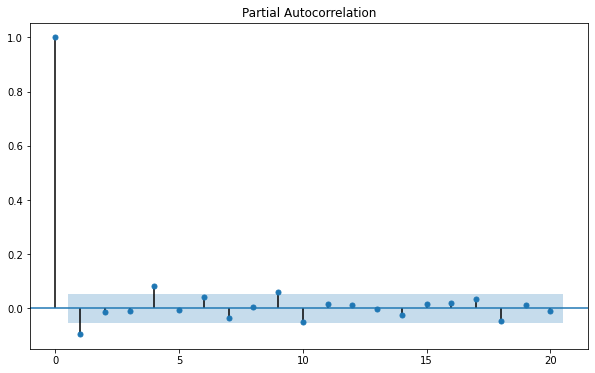

In [72]:
pltpacf(Stationary_df.dropna(),lags=20).show()
plt.show()

In [73]:
df_stock_train=df_stock.loc['2016-01-01':'2021-07-31']['Open']
df_stock_test=df_stock.loc['2021-07-31':]['Open']

In [74]:
df_stock_test

Date
2021-08-02    4893.500000
2021-08-03    4930.600098
2021-08-04    5017.000000
2021-08-05    5000.000000
2021-08-06    4950.000000
2021-08-09    4980.000000
2021-08-10    4930.899902
2021-08-11    4954.500000
2021-08-12    4929.950195
2021-08-13    4900.049805
2021-08-16    4945.549805
2021-08-17    4893.500000
2021-08-18    4911.850098
2021-08-20    4861.299805
2021-08-23    4849.000000
2021-08-24    4890.000000
2021-08-25    4863.450195
2021-08-26    4855.000000
2021-08-27    4846.649902
Name: Open, dtype: float64

In [75]:
df_stock

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,1154.000000,1165.000000,1145.550049,1162.500000,100178.0,4,1,1,7791.299805,19.449951
2016-01-04,1161.000000,1173.699951,1137.800049,1149.699951,233101.0,0,4,1,7784.649902,35.899902
2016-01-05,1147.000000,1157.500000,1138.500000,1147.500000,302272.0,1,5,1,7741.000000,19.000000
2016-01-06,1149.000000,1154.300049,1135.000000,1137.199951,392164.0,2,6,1,7568.299805,19.300049
2016-01-07,1115.000000,1136.550049,1115.000000,1126.949951,316523.0,3,7,1,7601.350098,21.550049
...,...,...,...,...,...,...,...,...,...,...
2021-08-23,4849.000000,4888.700195,4788.000000,4874.649902,410817.0,0,23,8,16624.599609,100.700195
2021-08-24,4890.000000,4912.149902,4792.850098,4863.200195,425873.0,1,24,8,16634.650391,119.299805
2021-08-25,4863.450195,4875.000000,4818.100098,4856.500000,345800.0,2,25,8,16636.900391,56.899902


In [76]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values[:14])):
    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)

In [77]:
predictions

[4881.89654773997,
 4892.4381002807195,
 4927.272614207876,
 5009.311432942523,
 5000.970225379941,
 4954.3878072490825,
 4977.74375063742,
 4935.025094198614,
 4952.725121130176,
 4931.9897013896825,
 4902.817903099244,
 4941.736662759405,
 4897.880080984317,
 4910.500329222549]

In [78]:
dummy_df['Open'] = predictions.copy()
dummy_df

,Open
Date,
2021-08-02,4881.896548
2021-08-03,4892.438100
2021-08-04,4927.272614
2021-08-05,5009.311433
2021-08-06,5000.970225
2021-08-09,4954.387807
2021-08-10,4977.743751
2021-08-11,4935.025094
2021-08-12,4952.725121


In [79]:
df_stock_for_test_lin[list(set(variables) & set(list(df_stock.columns)))] = dummy_df.copy()

In [80]:
print("Forecasted predictors test data")
df_stock_for_test_lin.head()

Forecasted predictors test data


,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2021-08-02,4881.896548,1.003968,1.007218,4928.950195,0.012690,0,2,8,1.023069,0.176543
2021-08-03,4892.438100,1.017137,1.008719,5006.850098,0.021029,1,3,8,1.037370,0.317806
2021-08-04,4927.272614,1.022906,1.021318,4964.250000,0.013759,2,4,8,1.041369,0.237184
2021-08-05,5009.311433,1.017159,1.012530,4923.549805,0.015311,3,5,8,1.035070,0.272602
2021-08-06,5000.970225,1.003249,1.005024,4916.000000,0.010502,4,6,8,1.037309,0.194046


In [81]:
df_stock_for_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.transform(df_stock_for_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])

In [82]:
model_for,variables_for,rmse_per_for = model_generator(df_stock_train_lin,df_stock_for_test_lin)

In [83]:
print(model_for.summary2())

                   Results: Ordinary least squares
Model:                OLS              Adj. R-squared:     0.999     
Dependent Variable:   Close            AIC:                13662.6638
Date:                 2021-09-14 14:15 BIC:                13751.4350
No. Observations:     1369             Log-Likelihood:     -6814.3   
Df Model:             16               F-statistic:        7.123e+04 
Df Residuals:         1352             Prob (F-statistic): 0.00      
R-squared:            0.999            Scale:              1248.6    
---------------------------------------------------------------------
                Coef.   Std.Err.     t     P>|t|    [0.025    0.975] 
---------------------------------------------------------------------
Open          4382.9999   4.1262 1062.2245 0.0000 4374.9053 4391.0944
Day of Week_0  381.0991   2.1942  173.6846 0.0000  376.7947  385.4035
Day of Week_1  382.2708   2.1760  175.6796 0.0000  378.0021  386.5394
Day of Week_2  382.7929   2.1569  177.4

In [85]:
print("RMSE Percentage for forecasted predictors",rmse_per_for,sep='\n')

RMSE Percentage for forecasted predictors
1.1964839437330288
